# Embed artworks

In [5]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
from pathlib import Path
from vllm import LLM
from tqdm.auto import tqdm
import json
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px
from matplotlib.lines import Line2D

In [ ]:
embeddings_path = Path("artwork_embeddings.npy")
paths_path = Path("artwork_paths.json")

if embeddings_path.exists() and paths_path.exists():
    embeddings = np.load(embeddings_path)
    print("Loaded embeddings:", embeddings.shape)

else:
    with open("../../artworks/prompt_10_20260413/successes.txt") as f:
        artwork_paths = f.read().splitlines()

    MODEL_PATH = "../../../links/projects/def-baudry/shared/huggingface/models--Qwen--Qwen3-Embedding-8B/snapshots/1d8ad4ca9b3dd8059ad90a75d4983776a23d44af"
    MODEL_PATH = str(Path(MODEL_PATH).resolve())
    
    print("Model exists:", Path(MODEL_PATH).exists())
    print("Model path:", MODEL_PATH)
    
    llm = LLM(
        model=MODEL_PATH,
        runner="pooling",
        convert="embed",
        dtype="bfloat16",
        model_impl="transformers",
        max_model_len=8192,
    )

    embeddings = []

    for artwork in tqdm(artwork_paths, desc="Embedding artworks"):
        text = Path(artwork).read_text(encoding="utf-8")

        output = llm.embed(
            [text],
            truncate_prompt_tokens=8192,
            use_tqdm=False,
        )[0]

        embeddings.append(output.outputs.embedding)

    embeddings = np.array(embeddings, dtype=np.float32)

    np.save(embeddings_path, embeddings)

    with open(paths_path, "w", encoding="utf-8") as f:
        json.dump([str(path) for path in artwork_paths], f, indent=2)

    print("Saved embeddings:", embeddings.shape)


Loaded embeddings: (19727, 4096)


## Find similar embeddings

In [6]:
class EmbeddingSearch:
    def __init__(
        self,
        embeddings_path="artwork_embeddings.npy",
        paths_path="artwork_paths.json",
    ):
        self.embeddings = np.load(embeddings_path).astype(np.float32)

        with open(paths_path, "r", encoding="utf-8") as f:
            self.paths = json.load(f)

        # Normalize once for cosine similarity
        norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self.embeddings = self.embeddings / np.maximum(norms, 1e-12)

        # Precompute path -> index lookup
        self.path_to_idx = {
            str(Path(path).resolve()): idx
            for idx, path in enumerate(self.paths)
        }

    def get_all_similarities_by_path(self, query_file_path, include_self=False):
        query_resolved = str(Path(query_file_path).resolve())

        if query_resolved not in self.path_to_idx:
            raise ValueError(f"File not found in index: {query_file_path}")

        query_idx = self.path_to_idx[query_resolved]
        query_embedding = self.embeddings[query_idx]

        # Similarity against every vector
        scores = self.embeddings @ query_embedding

        results = []

        for idx, score in enumerate(scores):
            if not include_self and idx == query_idx:
                continue

            results.append({
                "path": self.paths[idx],
                "score": float(score),
            })

        return results

    @staticmethod
    def top_k(results, k=10):
        return sorted(
            results,
            key=lambda x: x["score"],
            reverse=True,
        )[:k]

In [7]:
with open("../artworks/prompt_10_20260413/successes.txt") as f:
    artwork_paths = f.read().splitlines()

searcher = EmbeddingSearch(
    embeddings_path="artwork_embeddings.npy",
    paths_path="artwork_paths.json",
)

start = time.perf_counter()
all_results = searcher.get_all_similarities_by_path(
    query_file_path=artwork_paths[0],
    include_self=False,
)

In [8]:
topk = 10

top_results = searcher.top_k(all_results, k=topk)

for result in top_results:
    print(f"{result['score']:.4f} - {result['path']}")

elapsed = time.perf_counter() - start

print(f"Total time: {elapsed:.4f}s")

1.0000 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/usmanCodesjs/project15/sketch.js
1.0000 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/ZishannBro/c-19-TreasureHunt/sketch.js
1.0000 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/VANSHULABROL/PROJECT15/sketch.js
1.0000 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/Pencil12/Project_15/sketch.js
0.9999 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/RaghavMathur639/Project-15/sketch.js
0.9998 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/ZayOnyxLink/Class15Project/sketch.js
0.9998 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/jejthenoob/project-15/sketch.js
0.9998 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/Titanaboa596/COLLECTING-TREASURE-/Project-Template-C15-main/Project-Template-C15-main/sketch.js
0.9998 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/s

### Plot the unique similarity scores 

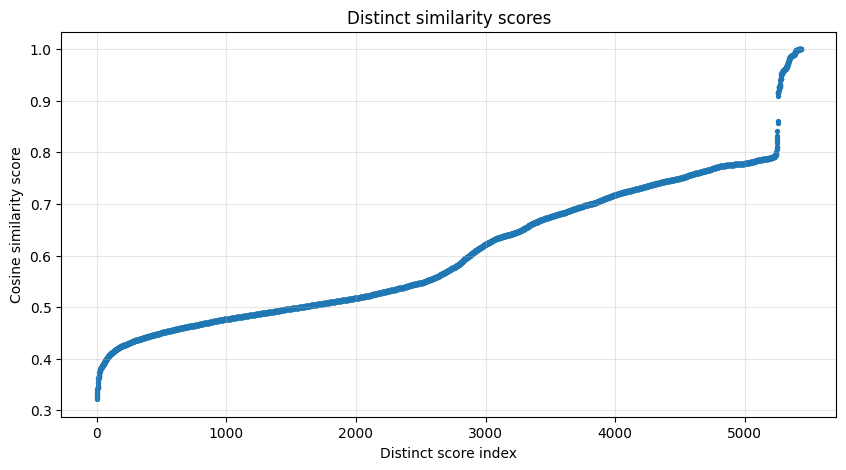

In [9]:
# all_results should be the full list returned by:
# all_results = searcher.get_all_similarities_by_path(...)

scores = np.array([result["score"] for result in all_results], dtype=np.float32)

# Distinct score values
distinct_scores = np.unique(scores)

# Sort for easier visualization
distinct_scores = np.sort(distinct_scores)

plt.figure(figsize=(10, 5))
plt.scatter(
    np.arange(len(distinct_scores)),
    distinct_scores,
    s=8,
)

plt.xlabel("Distinct score index")
plt.ylabel("Cosine similarity score")
plt.title("Distinct similarity scores")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
def top_k_below_threshold(all_results, threshold, k=10):
    filtered = [
        result
        for result in all_results
        if result["score"] < threshold
    ]

    filtered = sorted(
        filtered,
        key=lambda x: x["score"],
        reverse=True,
    )

    return filtered[:k]

threshold = 0.8
k = 10

top_results = top_k_below_threshold(
    all_results=all_results,
    threshold=threshold,
    k=k,
)

for result in top_results:
    print(f"{result['score']:.4f} - {result['path']}")

0.8000 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/Kumarshilu/Trex-Game.T/sketch.js
0.7992 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/ireneagoye/Infinite/sketch.js
0.7986 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/Ranisha-Agasti/My-game/sketch.js
0.7976 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/rakshansharma/PRO-39/sketch.js
0.7966 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/atha29/project-C11/sketch.js
0.7958 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/sun1627/Class-17-Scope-Of-Variables/sketch.js
0.7950 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/MS-aquib/trex-2/sketch.js
0.7949 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/SanjeevDharun/Trex-Game/sketch.js
0.7948 - /home/rpinter/links/projects/def-baudry/shared/data/artworks/src/saurabhgoel779gmailcom/Project18/sketch.js
0.7941 - /home/rpinter/links/

## T-SNE

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 19727 samples in 0.001s...
[t-SNE] Computed neighbors for 19727 samples in 2.161s...
[t-SNE] Computed conditional probabilities for sample 1000 / 19727
[t-SNE] Computed conditional probabilities for sample 2000 / 19727
[t-SNE] Computed conditional probabilities for sample 3000 / 19727
[t-SNE] Computed conditional probabilities for sample 4000 / 19727
[t-SNE] Computed conditional probabilities for sample 5000 / 19727
[t-SNE] Computed conditional probabilities for sample 6000 / 19727
[t-SNE] Computed conditional probabilities for sample 7000 / 19727
[t-SNE] Computed conditional probabilities for sample 8000 / 19727
[t-SNE] Computed conditional probabilities for sample 9000 / 19727
[t-SNE] Computed conditional probabilities for sample 10000 / 19727
[t-SNE] Computed conditional probabilities for sample 11000 / 19727
[t-SNE] Computed conditional probabilities for sample 12000 / 19727
[t-SNE] Computed conditional probabilities for sam

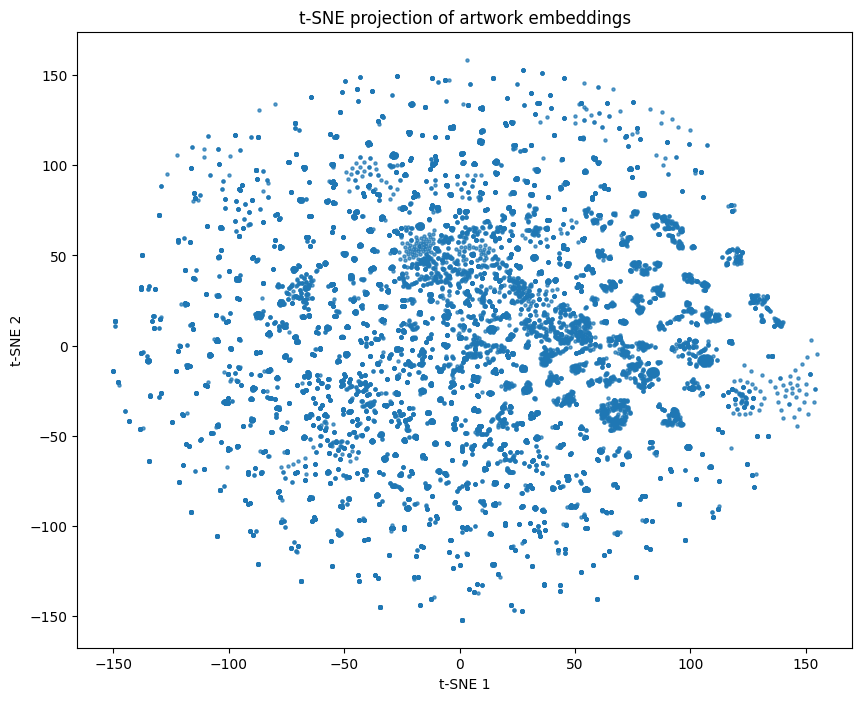

In [11]:
# Load embeddings
embeddings = np.load("artwork_embeddings.npy").astype(np.float32)

# Optional but recommended: normalize first
embeddings = embeddings / np.maximum(
    np.linalg.norm(embeddings, axis=1, keepdims=True),
    1e-12,
)

# Recommended before t-SNE when embeddings are huge
pca = PCA(n_components=50, random_state=42)
embeddings_50d = pca.fit_transform(embeddings)

# Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42,
    verbose=1,
)

embeddings_2d = tsne.fit_transform(embeddings_50d)

# Save result
np.save("artwork_embeddings_tsne_2d.npy", embeddings_2d)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    s=5,
    alpha=0.7,
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection of artwork embeddings")
plt.show()

In [12]:
TSNE_PATH = "artwork_embeddings_tsne_2d.npy"
PATHS_PATH = "artwork_paths.json"
PREDICTIONS_PATH = "../artworks/prompt_10_20260413/predictions.json"


def normalize_path(path):
    return str(Path(path).resolve())


def load_predictions(predictions_path):
    with open(predictions_path, "r", encoding="utf-8") as f:
        predictions = json.load(f)

    rows = []

    for item in predictions:
        file_path = item["file_path"]
        labels = item["predicted_labels"]

        entities = labels.get("entities", [])
        interaction = labels.get("interaction", [])
        outcome = labels.get("outcome", [])

        label_combination = (
            f"entities={'+'.join(entities)} | "
            f"interaction={'+'.join(interaction)} | "
            f"outcome={'+'.join(outcome)}"
        )

        rows.append({
            "file_path": file_path,
            "file_path_resolved": normalize_path(file_path),
            "entities": ", ".join(entities),
            "interaction": ", ".join(interaction),
            "outcome": ", ".join(outcome),
            "label_combination": label_combination,
        })

    return pd.DataFrame(rows)


# Load t-SNE coordinates
tsne_2d = np.load(TSNE_PATH)

# Load paths matching the embedding order
with open(PATHS_PATH, "r", encoding="utf-8") as f:
    artwork_paths = json.load(f)

tsne_df = pd.DataFrame({
    "file_path": artwork_paths,
    "file_path_resolved": [normalize_path(path) for path in artwork_paths],
    "tsne_x": tsne_2d[:, 0],
    "tsne_y": tsne_2d[:, 1],
})

# Load predictions
predictions_df = load_predictions(PREDICTIONS_PATH)

# Merge t-SNE with labels
plot_df = tsne_df.merge(
    predictions_df.drop(columns=["file_path"]),
    on="file_path_resolved",
    how="left",
)

# Fill missing predictions
plot_df["label_combination"] = plot_df["label_combination"].fillna("missing_prediction")
plot_df["entities"] = plot_df["entities"].fillna("")
plot_df["interaction"] = plot_df["interaction"].fillna("")
plot_df["outcome"] = plot_df["outcome"].fillna("")

plot_df.head()

,file_path,file_path_resolved,tsne_x,tsne_y,entities,interaction,outcome,label_combination
0,/home/rpinter/links/projects/def-baudry/shared...,/lustre09/project/6097821/shared/data/artworks...,99.496223,20.299402,"processed_image, synthesized_image, randomness",yes,"visual, time_based",entities=processed_image+synthesized_image+ran...
1,/home/rpinter/links/projects/def-baudry/shared...,/lustre09/project/6097821/shared/data/artworks...,67.913330,3.330680,"processed_audio, processed_image, synthesized_...",yes,"visual, auditory, time_based",entities=processed_audio+processed_image+synth...
2,/home/rpinter/links/projects/def-baudry/shared...,/lustre09/project/6097821/shared/data/artworks...,85.886154,-18.496237,"processed_image, synthesized_image, randomness",yes,"visual, time_based",entities=processed_image+synthesized_image+ran...
3,/home/rpinter/links/projects/def-baudry/shared...,/lustre09/project/6097821/shared/data/artworks...,76.783798,24.785658,"processed_image, synthesized_image, synthesize...",yes,"visual, auditory, time_based",entities=processed_image+synthesized_image+syn...
4,/home/rpinter/links/projects/def-baudry/shared...,/lustre09/project/6097821/shared/data/artworks...,63.717262,-20.759743,"processed_image, synthesized_image, randomness",yes,"visual, time_based",entities=processed_image+synthesized_image+ran...


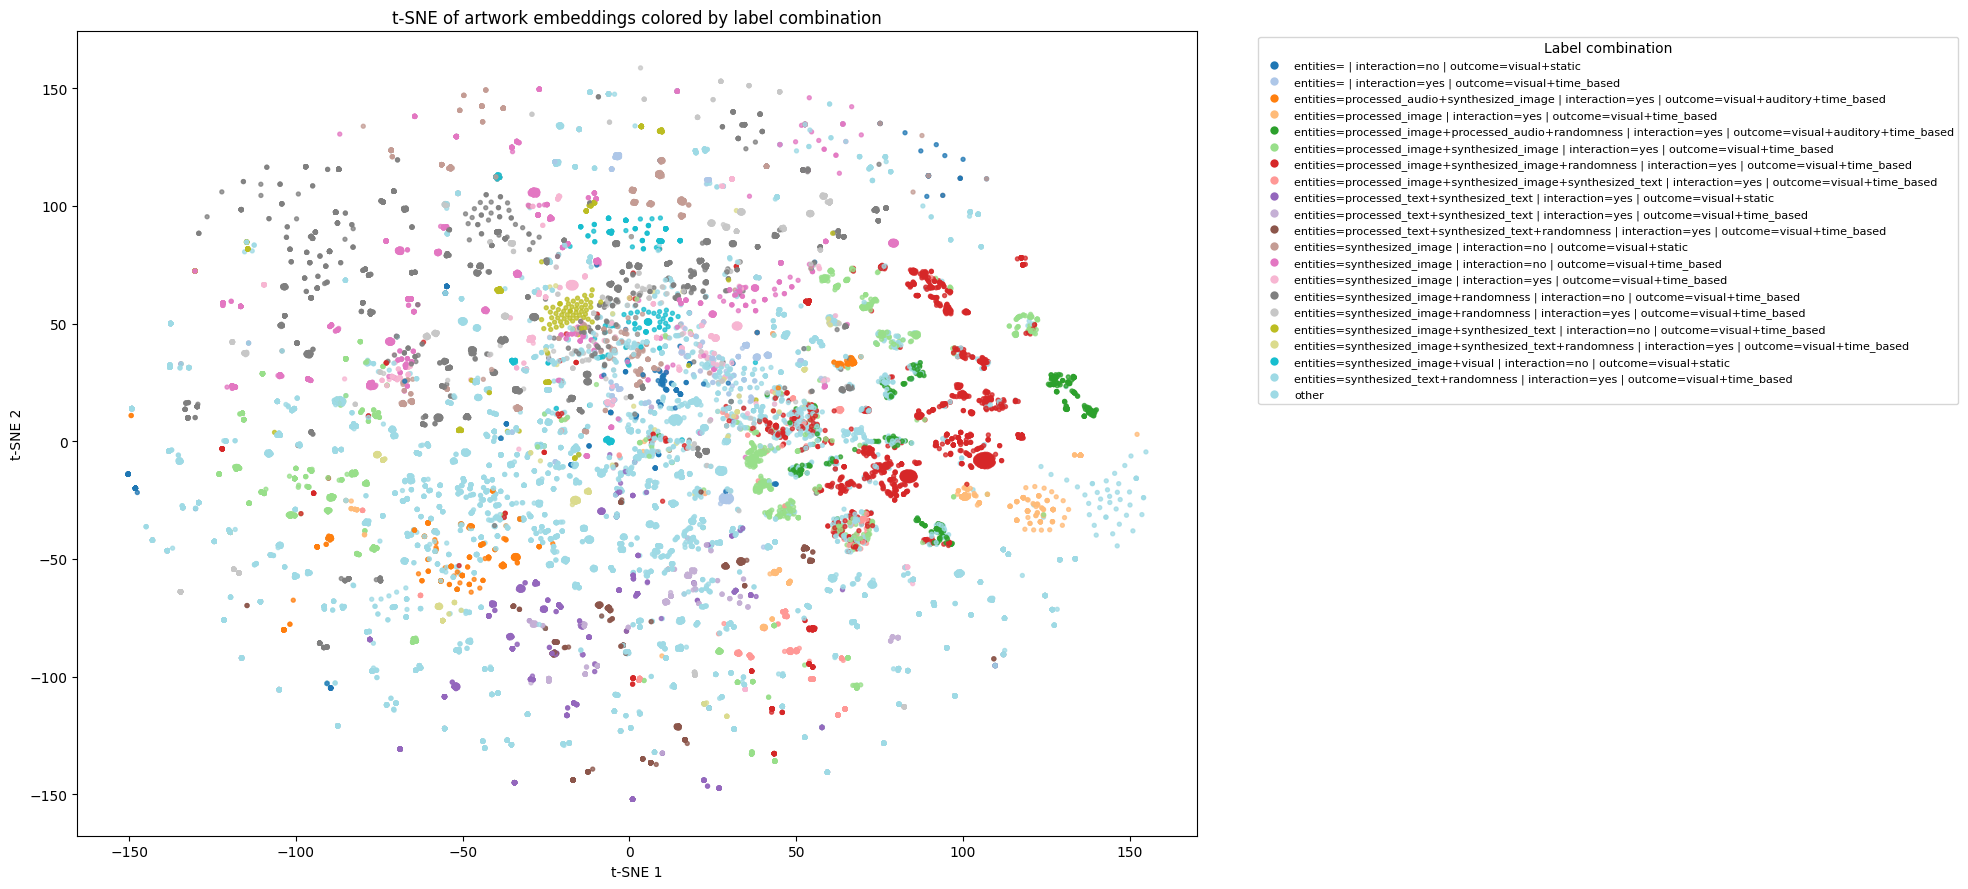

In [16]:
top_n_labels = 20

top_labels = (
    plot_df["label_combination"]
    .value_counts()
    .head(top_n_labels)
    .index
)

plot_df["label_group"] = np.where(
    plot_df["label_combination"].isin(top_labels),
    plot_df["label_combination"],
    "other",
)

label_categories = sorted(plot_df["label_group"].unique())
label_to_id = {label: i for i, label in enumerate(label_categories)}

plot_df["label_id"] = plot_df["label_group"].map(label_to_id)

plt.figure(figsize=(20, 9))

scatter = plt.scatter(
    plot_df["tsne_x"],
    plot_df["tsne_y"],
    c=plot_df["label_id"],
    s=8,
    alpha=0.75,
    cmap="tab20",
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of artwork embeddings colored by label combination")

# Legend
handles = []

for label, label_id in label_to_id.items():
    handles.append(
        plt.Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            label=label,
            markersize=6,
            markerfacecolor=scatter.cmap(scatter.norm(label_id)),
            markeredgecolor="none",
        )
    )

plt.legend(
    handles=handles,
    title="Label combination",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8,
)

plt.tight_layout()
plt.show()

This plot visualizes the 2D t-SNE projection of the artwork embeddings. Each point represents one artwork file. 

- The marker shape encodes the temporal behavior of the artwork: circles represent static artworks, while triangles represent time-based artworks. 
- The marker fill encodes interaction: filled markers indicate interactive artworks, while empty markers indicate non-interactive artworks.
- Colors represent a simplified content family derived from the predicted labels, such as image-based, audio-based, text-based, multimodal, randomness-only, or - unknown.

This encoding allows us to inspect whether artworks with similar embeddings also share similar predicted characteristics.

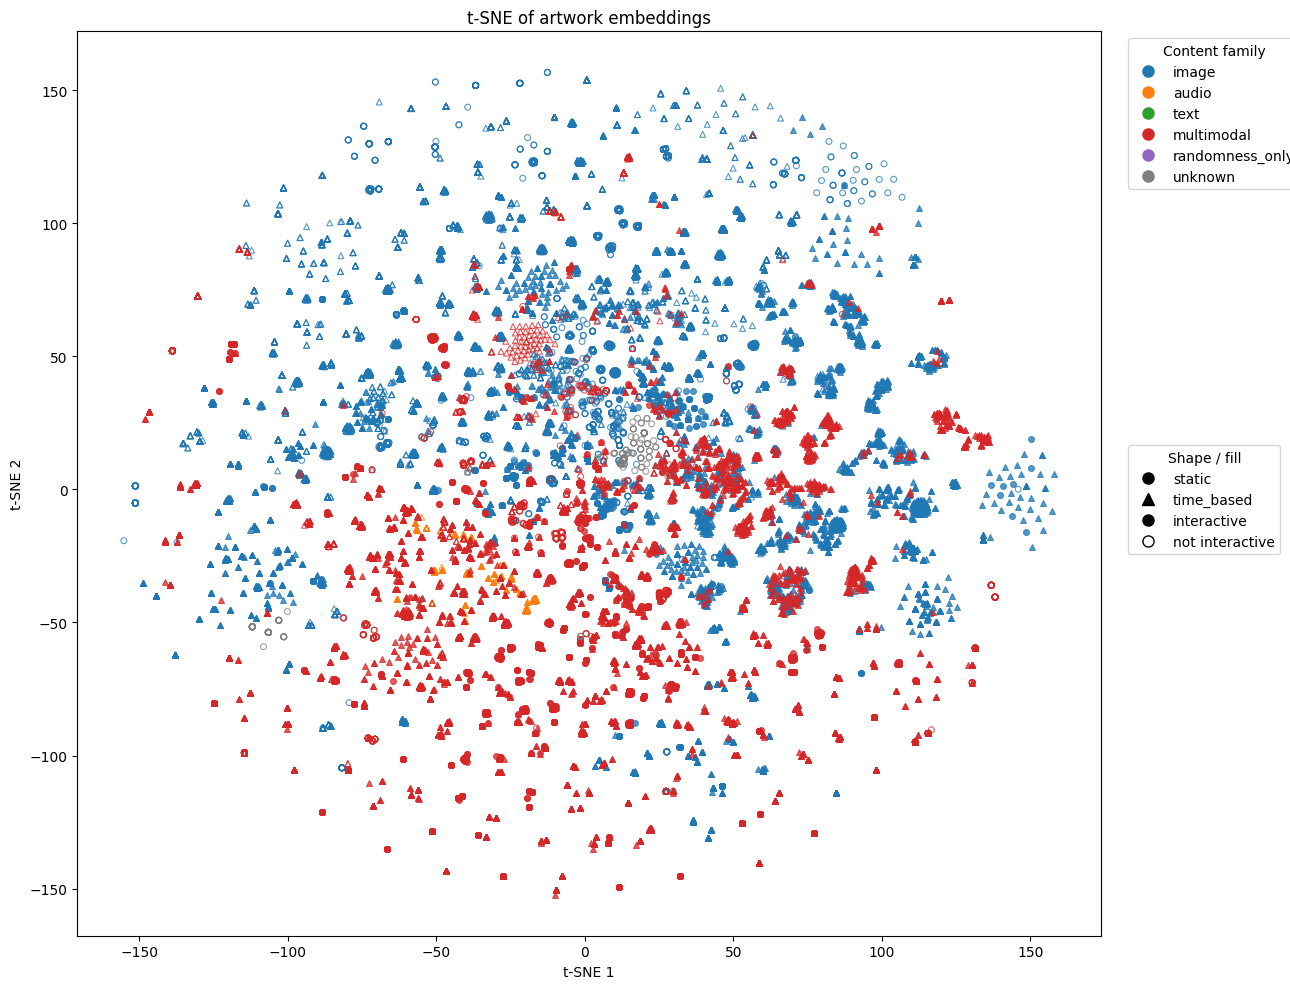

In [28]:
PREDICTIONS_PATH = "../artworks/prompt_10_20260413/predictions.json"
# If needed:
# PREDICTIONS_PATH = "art-in-swh/artworks/prompt_10_20260413/predictions.json"


def normalize_path(path):
    return str(Path(path).resolve())


def get_time_type(labels):
    outcome = set(labels.get("outcome", []))

    if "time_based" in outcome:
        return "time_based"
    if "static" in outcome:
        return "static"

    return "unknown_time"


def get_interaction_type(labels):
    interaction = set(labels.get("interaction", []))

    if "yes" in interaction:
        return "interactive"
    if "no" in interaction:
        return "not_interactive"

    return "unknown_interaction"


def get_content_family(labels):
    entities = set(labels.get("entities", []))
    outcome = set(labels.get("outcome", []))

    has_image = bool(
        {"processed_image", "synthesized_image"} & entities
        or "visual" in outcome
    )

    has_audio = bool(
        {"processed_audio", "synthesized_sound"} & entities
        or "auditory" in outcome
    )

    has_text = bool(
        {"processed_text", "synthesized_text"} & entities
    )

    has_randomness = "randomness" in entities

    n_modalities = sum([has_image, has_audio, has_text])

    if n_modalities >= 2:
        return "multimodal"
    if has_image:
        return "image"
    if has_audio:
        return "audio"
    if has_text:
        return "text"
    if has_randomness:
        return "randomness_only"

    return "unknown"


# Make sure plot_df has resolved paths
if "file_path_resolved" not in plot_df.columns:
    plot_df["file_path_resolved"] = plot_df["file_path"].apply(normalize_path)


# Load predictions
with open(PREDICTIONS_PATH, "r", encoding="utf-8") as f:
    predictions = json.load(f)


pred_rows = []

for item in predictions:
    labels = item["predicted_labels"]

    pred_rows.append({
        "file_path_resolved": normalize_path(item["file_path"]),
        "content_family": get_content_family(labels),
        "time_type": get_time_type(labels),
        "interaction_type": get_interaction_type(labels),
    })


pred_df = pd.DataFrame(pred_rows)


# Merge only the columns we need
plot_df = plot_df.drop(
    columns=["content_family", "time_type", "interaction_type"],
    errors="ignore",
).merge(
    pred_df,
    on="file_path_resolved",
    how="left",
)


plot_df["content_family"] = plot_df["content_family"].fillna("unknown")
plot_df["time_type"] = plot_df["time_type"].fillna("unknown_time")
plot_df["interaction_type"] = plot_df["interaction_type"].fillna("unknown_interaction")

plot_df[["content_family", "time_type", "interaction_type"]].value_counts().head()

color_map = {
    "image": "tab:blue",
    "audio": "tab:orange",
    "text": "tab:green",
    "multimodal": "tab:red",
    "randomness_only": "tab:purple",
    "unknown": "tab:gray",
}

marker_map = {
    "static": "o",
    "time_based": "^",
    "unknown_time": "s",
}

plt.figure(figsize=(13, 10))

for content_family, family_df in plot_df.groupby("content_family"):
    for time_type, time_df in family_df.groupby("time_type"):
        for interaction_type, sub_df in time_df.groupby("interaction_type"):
            color = color_map.get(content_family, "tab:gray")
            marker = marker_map.get(time_type, "s")

            is_interactive = interaction_type == "interactive"

            plt.scatter(
                sub_df["tsne_x"],
                sub_df["tsne_y"],
                marker=marker,
                s=18,
                alpha=0.75,
                facecolors=color if is_interactive else "none",
                edgecolors=color,
                linewidths=0.8,
            )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of artwork embeddings")

# Color legend
color_handles = [
    Line2D(
        [], [], marker="o", linestyle="",
        markerfacecolor=color,
        markeredgecolor=color,
        label=label,
        markersize=8,
    )
    for label, color in color_map.items()
]

# Shape legend
shape_handles = [
    Line2D(
        [], [], marker="o", linestyle="",
        color="black",
        markerfacecolor="black",
        label="static",
        markersize=8,
    ),
    Line2D(
        [], [], marker="^", linestyle="",
        color="black",
        markerfacecolor="black",
        label="time_based",
        markersize=8,
    ),
]

# Fill legend
fill_handles = [
    Line2D(
        [], [], marker="o", linestyle="",
        markerfacecolor="black",
        markeredgecolor="black",
        label="interactive",
        markersize=8,
    ),
    Line2D(
        [], [], marker="o", linestyle="",
        markerfacecolor="none",
        markeredgecolor="black",
        label="not interactive",
        markersize=8,
    ),
]

legend1 = plt.legend(
    handles=color_handles,
    title="Content family",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.gca().add_artist(legend1)

plt.legend(
    handles=shape_handles + fill_handles,
    title="Shape / fill",
    bbox_to_anchor=(1.02, 0.55),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [18]:
plot_df = plot_df.merge(
    metadata_df[["file_path", "content_family", "time_type"]],
    on="file_path",
    how="left",
)

paths = plot_df.loc[
    (plot_df["content_family"] == "audio") &
    (plot_df["time_type"] == "time_based"),
    "file_path"
]
for path in paths[:10]:
    print(path)

NameError: name 'metadata_df' is not defined

In [ ]:
def get_nearby_points_2d(plot_df, x, y, top_k=10):
    df = plot_df.copy()

    df["tsne_distance"] = np.sqrt(
        (df["tsne_x"] - x) ** 2 +
        (df["tsne_y"] - y) ** 2
    )

    return df.sort_values("tsne_distance").head(top_k)

nearby = get_nearby_points_2d(
    plot_df,
    x=-20,
    y=50,
    top_k=10,
)


for path in nearby["file_path"][:10]:
    print(path)

### No entities?

In [ ]:
for path in plot_df[plot_df["entities"] == ""]["file_path"][:10]:
    print(path)

### Extra: Daniel Shiffman?

In [ ]:
search_string = "daniel shiffman"

matches = []

for path in tqdm(artwork_paths, desc="Scanning files"):
    path = Path(path)

    try:
        text = path.read_text(encoding="utf-8", errors="ignore")

        if search_string in text.lower():
            matches.append(str(path))

    except Exception as e:
        print(f"Could not read {path}: {e}")

print(f"Found {len(matches)} files containing 'Daniel Shiffman'")

In [ ]:
def contains_daniel_shiffman(path):
    try:
        text = Path(path).read_text(encoding="utf-8", errors="ignore")
        return "daniel shiffman" in text.lower()
    except Exception:
        return False


# Add boolean column
plot_df["mentions_daniel_shiffman"] = plot_df["file_path"].apply(contains_daniel_shiffman)

# Check counts
print(plot_df["mentions_daniel_shiffman"].value_counts())

color_map = {
    True: "tab:red",
    False: "tab:gray",
}

label_map = {
    True: "Mentions Daniel Shiffman",
    False: "Does not mention Daniel Shiffman",
}

plt.figure(figsize=(12, 9))

for value, sub_df in plot_df.groupby("mentions_daniel_shiffman"):
    plt.scatter(
        sub_df["tsne_x"],
        sub_df["tsne_y"],
        s=18 if value else 8,
        alpha=0.85 if value else 0.25,
        color=color_map[value],
        label=label_map[value],
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of artwork embeddings\nHighlighting files that mention Daniel Shiffman")

plt.legend()
plt.tight_layout()
plt.show()

## Distribution of label combination

In [ ]:
combination_counts = (
    plot_df["label_combination"]
    .value_counts()
    .reset_index()
)

combination_counts.columns = ["label_combination", "count"]

# Optional: plot only top N combinations
# top_n = 100
# combination_counts_top = combination_counts.head(top_n)
combination_counts_top = combination_counts

plt.figure(figsize=(25, 45))

plt.barh(
    combination_counts_top["label_combination"][::-1],
    combination_counts_top["count"][::-1],
)

plt.xlabel("Count")
plt.ylabel("Label combination")
plt.title(f"Top {top_n} label combinations")

plt.tight_layout()
plt.show()